# EDA

## Team norms & best practices:
- Don't push directly to main branch, always branch + make a merge request
- Add helpfull notes and insights in markdown cells to help guide the reader
- Keep all imports at the top of the notebook, don't let random imports dangle all over the notebook (AI LOVES importing pandas over and over again lol)
- Try to have EDA tell a story and follow a logical flow

In [ ]:
# PLEASE do not add duplicates to this cell
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import os
import random
import re
from urllib.parse import unquote
from IPython.display import display
from sklearn.cluster import KMeans
import numpy as np

## Load tabular data and clean

In [3]:
df = pd.read_csv("../data/npc.csv")

# Data cleaning

# Gender: collapse anything besides Male/Female to Other
df["Gender"] = df["Gender"].apply(lambda x: x if x in ("Male", "Female") else "Other")

# Members: treat "? (edit)" as Yes
df["Members"] = df["Members"].replace("? (edit)", "Yes")

# Race → Class, with value normalization
df = df.rename(columns={"Race": "Class"})
df["Class"] = df["Class"].replace({
    "Citizen of Arceuus": "Human",
    "Dwarf ( Imcando-descendant )": "Dwarf"
})

## Tabular data coverage

In [6]:
# counts and missing values
print(df.shape)

coverage = pd.DataFrame({
    "n_present": df.notna().sum(),
    "pct_present": (df.notna().mean() * 100).round(1)
}).sort_values("pct_present")
coverage

(4443, 23)


,n_present,pct_present
Respawn time,2,0.0
Size,7,0.2
Also called,39,0.9
Combat level,225,5.1
Removal,460,10.4
Shop,563,12.7
Quest,1450,32.6
lon,3102,69.8
lat,3102,69.8
Options,3340,75.2


## Class, Gender, Members (free-to-play or pay-to-play) counts

In [4]:
df['Class'].value_counts().head(15)

Class
Human         2212
Dwarf          255
Elf            150
Gnome          142
Ghost           79
Vampyre         65
Cat             56
Monkey          45
Bird            41
Dorgeshuun      40
Troll           39
Goblin          37
Dog             30
Demon           29
Undead          28
Name: count, dtype: int64

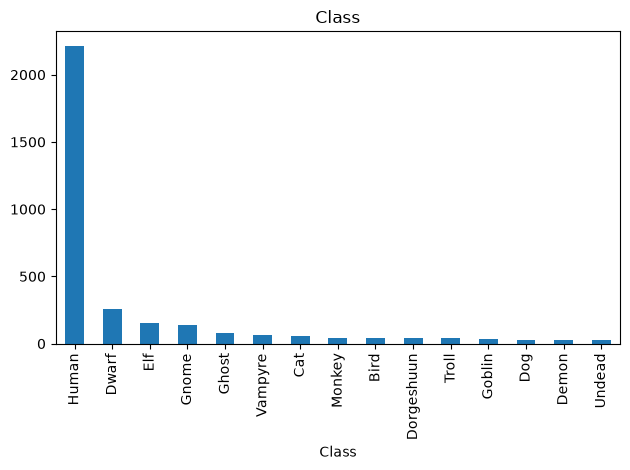

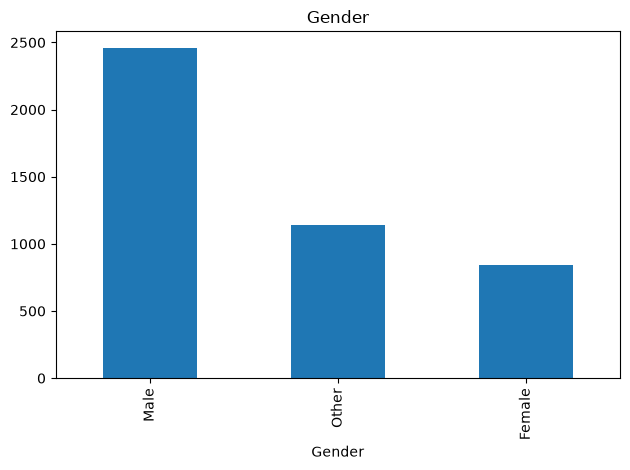

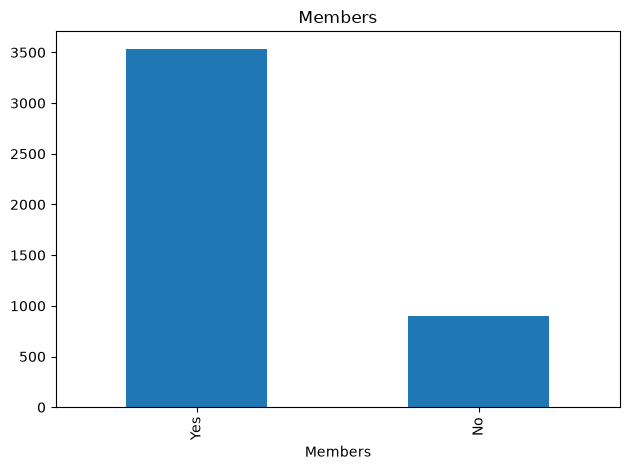

In [10]:
# Univariate analysis
for col in ["Class", "Gender", "Members"]:
    df[col].value_counts().head(15).plot(kind="bar", title=col)
    plt.tight_layout()
    plt.savefig(f"../img/univariate_{col}.png")
    plt.show()

## Location

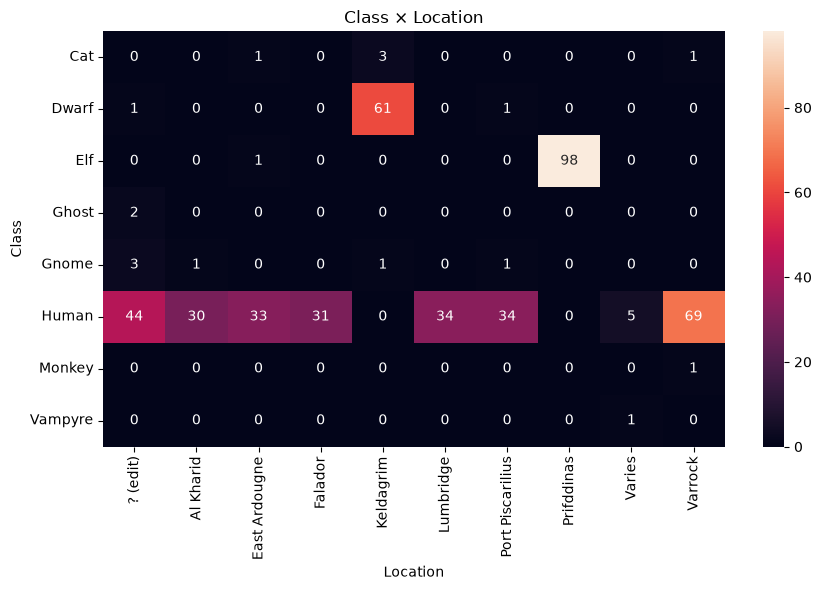

In [ ]:
# Bivariate analysis (class x location)
top_classes = df["Class"].value_counts().head(8).index
top_locs = df["Location"].value_counts().head(10).index

pivot_location = pd.crosstab(
    df[df["Class"].isin(top_classes)]["Class"],
    df[df["Class"].isin(top_classes) & df["Location"].isin(top_locs)]["Location"]
)

plt.figure(figsize=(9, 6))
sns.heatmap(pivot_location, annot=True, fmt="d", cmap="rocket")
plt.title("Class × Location")
plt.tight_layout()
plt.savefig("../img/bivariate_class_location.png")
plt.show()

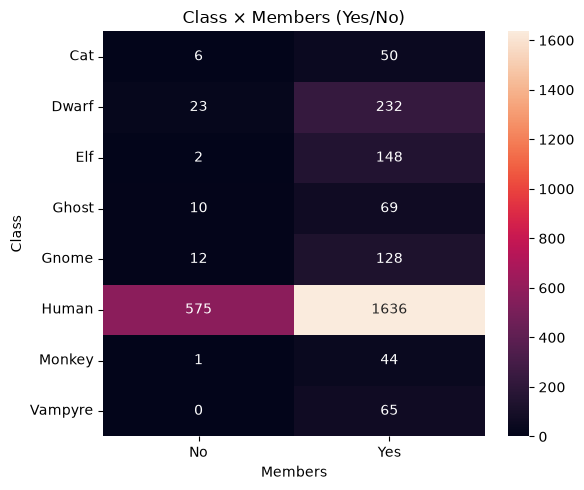

In [12]:
# Bivariate analysis (class x members)
pivot_members = pd.crosstab(
    df[df["Class"].isin(top_classes)]["Class"],
    df[df["Class"].isin(top_classes)]["Members"]
)

plt.figure(figsize=(6, 5))
sns.heatmap(pivot_members, annot=True, fmt="d", cmap="rocket")
plt.title("Class × Members (Yes/No)")
plt.tight_layout()
plt.savefig("../img/bivariate_class_members.png")
plt.show()

# Image stuff

## Dimensions

corrupt/unreadable: 0
total readable: 4193


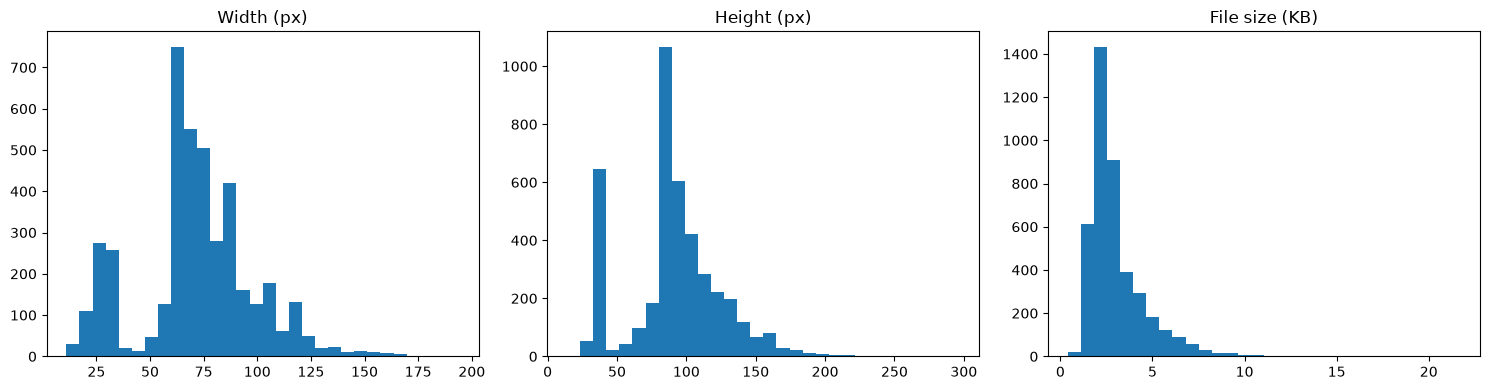

In [ ]:
# Check image existence and dimensions (histogram of file sizes, widths, heights)
sizes, widths, heights, corrupt = [], [], [], []
for f in os.listdir("../data/chatheads"):
    fp = f"../data/chatheads/{f}"
    try:
        with Image.open(fp) as im:
            w, h = im.size
            widths.append(w)
            heights.append(h)
            sizes.append(os.path.getsize(fp))
    except Exception:
        corrupt.append(f)

print(f"corrupt/unreadable: {len(corrupt)}")
print(f"total readable: {len(widths)}")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].hist(widths, bins=30); axes[0].set_title("Width (px)")
axes[1].hist(heights, bins=30); axes[1].set_title("Height (px)")
axes[2].hist([s / 1024 for s in sizes], bins=30); axes[2].set_title("File size (KB)")
plt.tight_layout()
plt.savefig("../img/image_dim_size_histograms.png")
plt.show()

## Summary grid

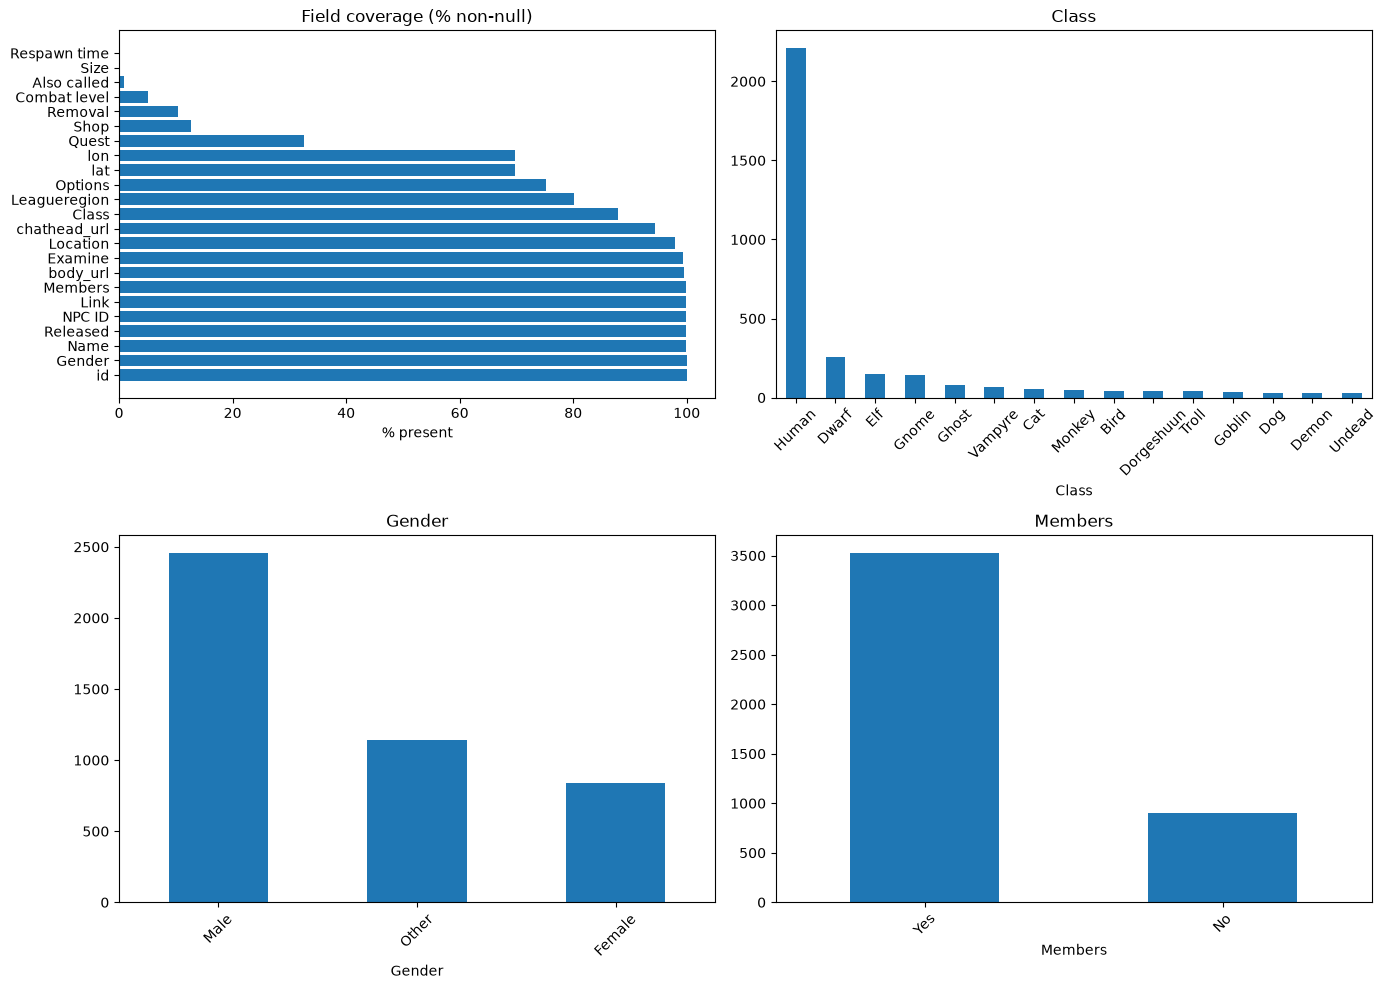

In [ ]:
# coverage + univariate summary
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Top-left: coverage table as a horizontal bar chart (easier to read than a raw table in a figure)
axes[0, 0].barh(coverage.index[::-1], coverage["pct_present"][::-1])
axes[0, 0].set_title("Field coverage (% non-null)")
axes[0, 0].set_xlabel("% present")

# Top-right, bottom-left, bottom-right: the three univariate categoricals
cols = ["Class", "Gender", "Members"]
positions = [(0, 1), (1, 0), (1, 1)]
for col, (r, c) in zip(cols, positions):
    df[col].value_counts().head(15).plot(kind="bar", ax=axes[r, c], title=col)
    axes[r, c].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig("../img/eda_summary_combined.png", dpi=150)
plt.show()

## View the images

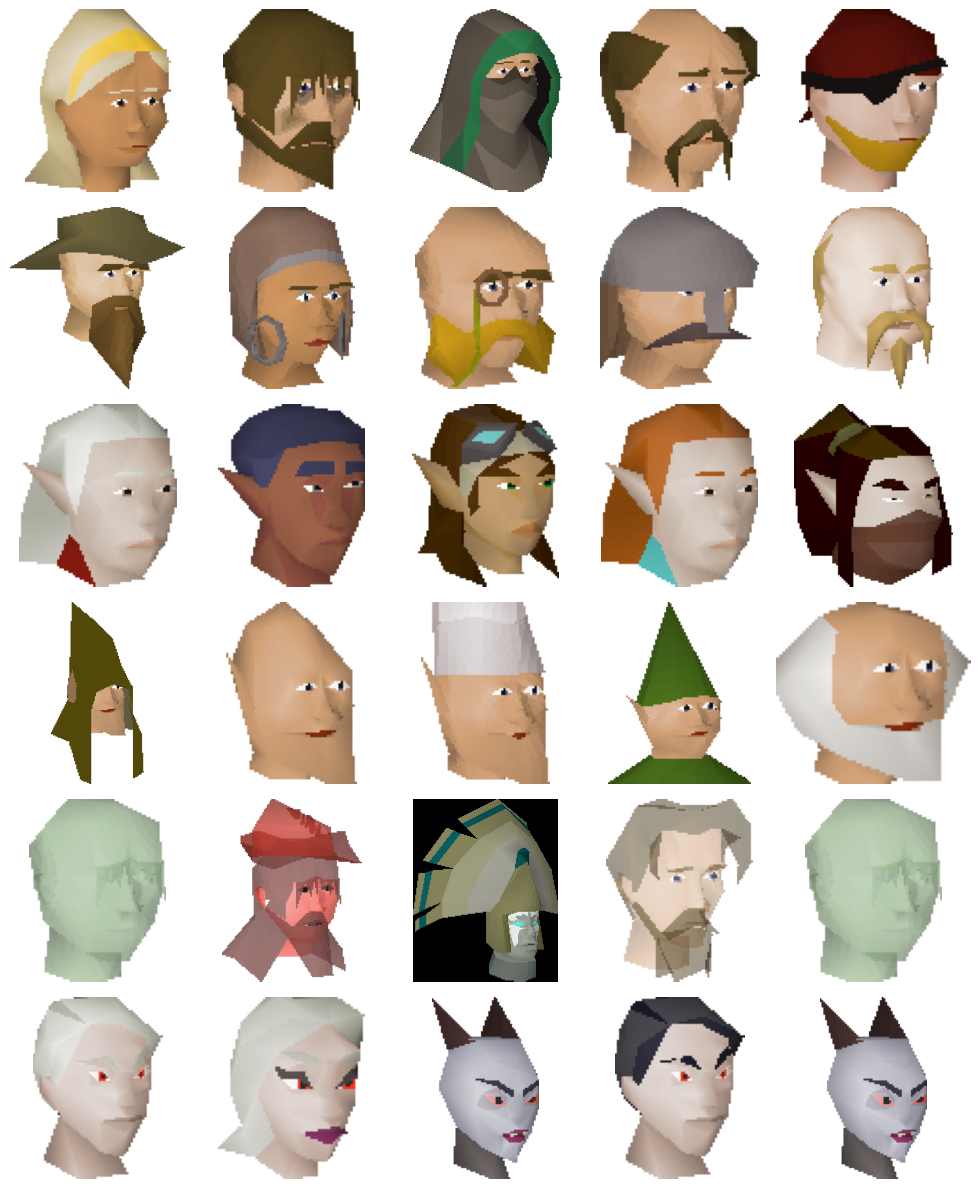

In [5]:
# Grid per class
df["has_chathead"] = df["chathead_url"].notna() & df["id"].apply(lambda i: os.path.exists(f"../data/chatheads/{i}.png"))


top_classes = df["Class"].value_counts().head(6).index.tolist()
n_samples = 5

fig, axes = plt.subplots(len(top_classes), n_samples, figsize=(n_samples * 2, len(top_classes) * 2))

for row, cls in enumerate(top_classes):
    cls_df = df[(df["Class"] == cls) & (df["has_chathead"])]
    sample_ids = cls_df["id"].sample(min(n_samples, len(cls_df)), random_state=42).tolist()
    for col, npc_id in enumerate(sample_ids):
        ax = axes[row, col]
        try:
            img = Image.open(f"../data/chatheads/{npc_id}.png")
            ax.imshow(img)
        except Exception:
            ax.text(0.5, 0.5, "missing", ha="center")
        ax.axis("off")
        if col == 0:
            ax.set_ylabel(cls, fontsize=10, rotation=0, labelpad=40)

plt.tight_layout()
#plt.savefig("../img/sample_grid_by_class.png")
plt.show()

## Random sample of NPCs + their image + chathead

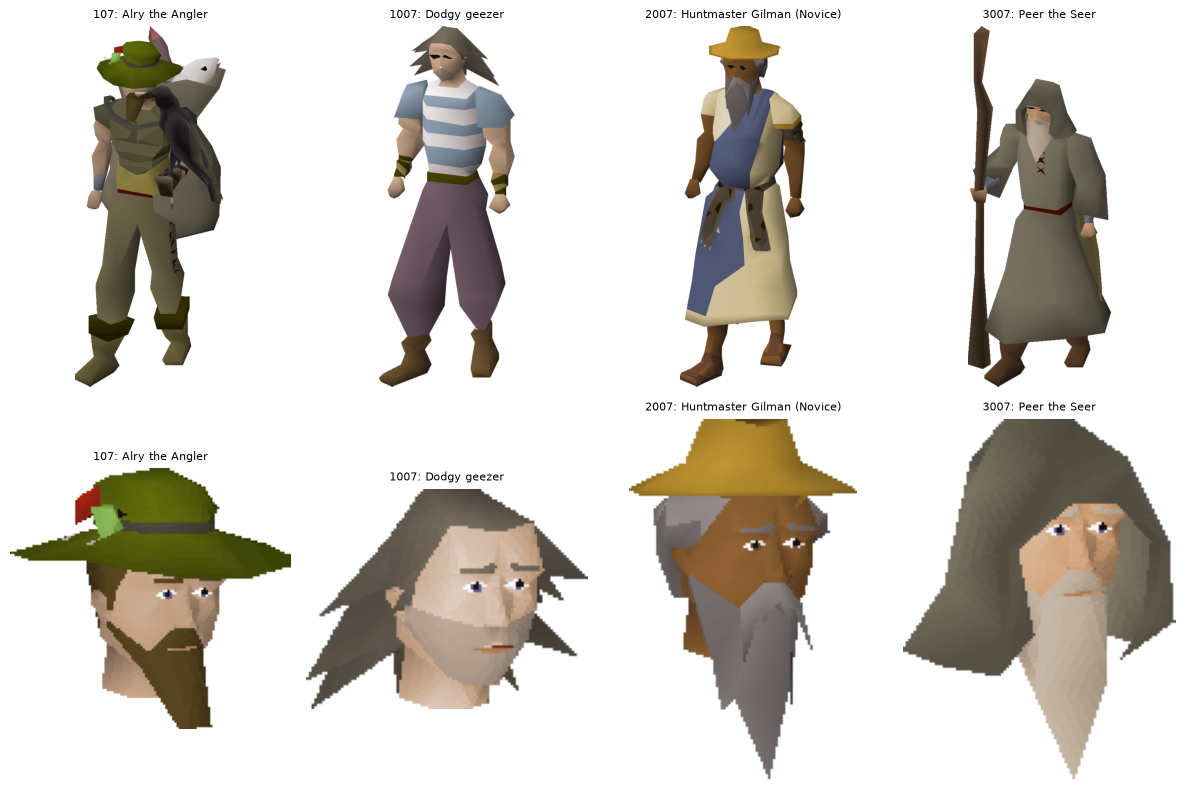

In [ ]:
check_ids = [107, 1007, 2007, 3007]

fig, axes = plt.subplots(2, len(check_ids), figsize=(len(check_ids) * 3, 8))
for col, npc_id in enumerate(check_ids):
    name = df.loc[df["id"] == npc_id, "Name"].values[0]
    for row, folder in enumerate(["bodies", "chatheads"]):
        ax = axes[row, col]
        try:
            img = Image.open(f"../data/{folder}/{npc_id}.png")
            ax.imshow(img)
        except:
            ax.text(0.5, 0.5, "missing", ha="center")
        ax.set_title(f"{npc_id}: {name}", fontsize=8)
        ax.set_ylabel(folder, fontsize=8)
        ax.axis("off")
plt.tight_layout()
plt.show()

## Random sample of NPCs with no chatheads

Not all NPCs can be spoken to, therefore that have no chathead!

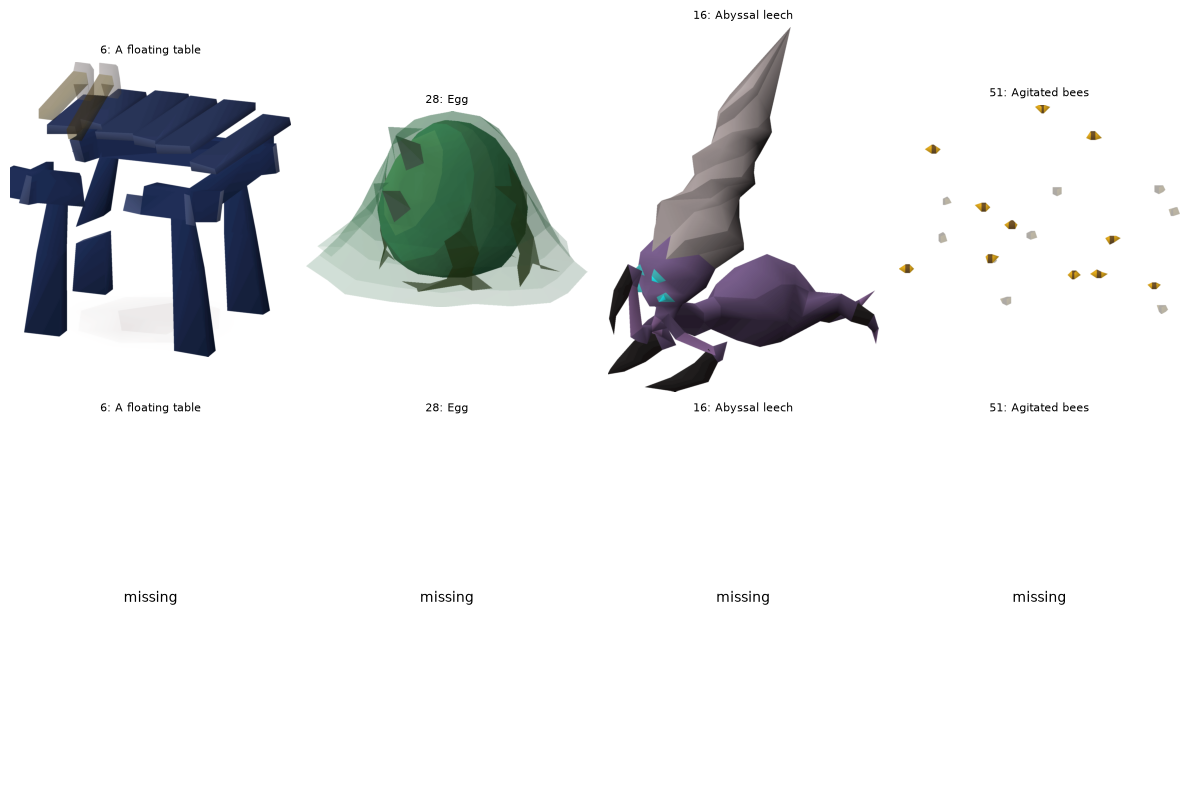

In [10]:
check_ids = [6, 28, 16, 51]

fig, axes = plt.subplots(2, len(check_ids), figsize=(len(check_ids) * 3, 8))
for col, npc_id in enumerate(check_ids):
    name = df.loc[df["id"] == npc_id, "Name"].values[0]
    for row, folder in enumerate(["bodies", "chatheads"]):
        ax = axes[row, col]
        try:
            img = Image.open(f"../data/{folder}/{npc_id}.png")
            ax.imshow(img)
        except:
            ax.text(0.5, 0.5, "missing", ha="center")
        ax.set_title(f"{npc_id}: {name}", fontsize=8)
        ax.set_ylabel(folder, fontsize=8)
        ax.axis("off")
plt.tight_layout()
plt.show()

## On missing chatheads: we captured a wide-range by blindly sampling all "NPC"s

Notice how the "NPCs" include an animated table, an egg, a monster, and a beeswarm. NPCs just in that they are moving and have interaction with the player, but not really "characters" in the traditional sense.

This actually gets at a larger point. If we want to build an 'average' NPC or a NPC class classifier, animated tables and swarms of bees are 'outlier' NPCs.

Might be worth limiting our data to just NPCs who we can talk to. We scraped `Options` from the infobox, so we could use those to filter our analysis. We'd just look for NPCs that have Talk-to.

In [30]:
df["Options"].value_counts().head(20)

Options
Talk-to                                          1895
Talk-to, Trade                                    374
Talk-to, Pickpocket                               116
Talk-to, Bank, Collect                             45
Take                                               40
Harvest                                            39
Talk-to, Pick-up                                   36
Talk-to, Pay, Trade                                33
Talk-to, Travel                                    30
Attack                                             25
Talk-To                                            24
Pet                                                23
Talk-to, Metamorphosis, Pick-up                    20
Catch                                              15
Talk-to, Trade, Customise-boat, Retrieve-boat      13
Talk-to, Assignment, Trade, Rewards                13
Retrieve                                           13
Talk-to, Escort, Supply                            12
Talk-to, Check-Appro

Actually, I spot-checked a bunch, and there are several NPCs who do indeed talk, but the wiki is missing "Options" for them OR the NPC only talks to you in a quest and is prompted by a trigger other than player clicking "Talk-to". So better source of truth would be `df["has_chathead"]`

In [9]:
df["has_chathead"].value_counts()

has_chathead
True     3477
False     966
Name: count, dtype: int64

## Finally filtering down

And conducting further EDA on just NPCs with a chathead

In [16]:
df_chat = df[df["has_chathead"]].copy()

# Most dominant colors across all chatheads

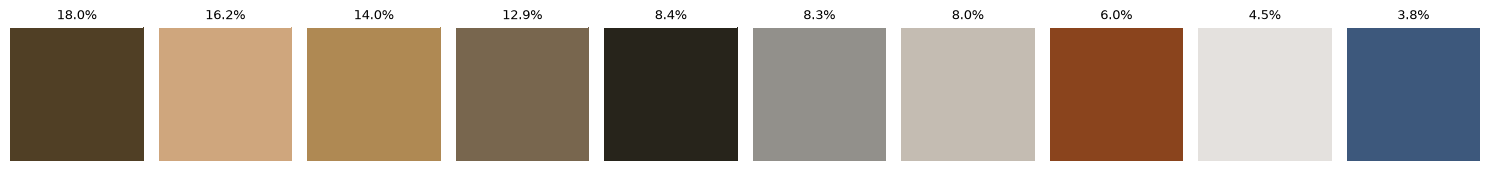

In [22]:

all_pixels = []

for npc_id in df[df["has_chathead"]]["id"]:
    try:
        img = Image.open(f"../data/chatheads/{npc_id}.png").convert("RGBA")
        arr = np.array(img).reshape(-1, 4)
        arr = arr[arr[:, 3] > 0]
        arr = arr[:, :3]
        all_pixels.append(arr)
    except:
        pass

all_pixels = np.vstack(all_pixels)

# sample for speed - kmeans on 50M pixels would take forever
sample = all_pixels[np.random.default_rng(42).choice(len(all_pixels), size=100_000, replace=False)]

kmeans = KMeans(n_clusters=10, random_state=42, n_init=5)
kmeans.fit(sample)

counts = np.bincount(kmeans.labels_)
colors = kmeans.cluster_centers_[np.argsort(-counts)].astype(int)
pcts = counts[np.argsort(-counts)] / counts.sum() * 100

fig, axes = plt.subplots(1, 10, figsize=(15, 2))
for ax, color, pct in zip(axes, colors, pcts):
    ax.imshow([[color]])
    ax.set_title(f"{pct:.1f}%", fontsize=9)
    ax.axis("off")
plt.tight_layout()
plt.show()

# Most dominant colors across all bodies

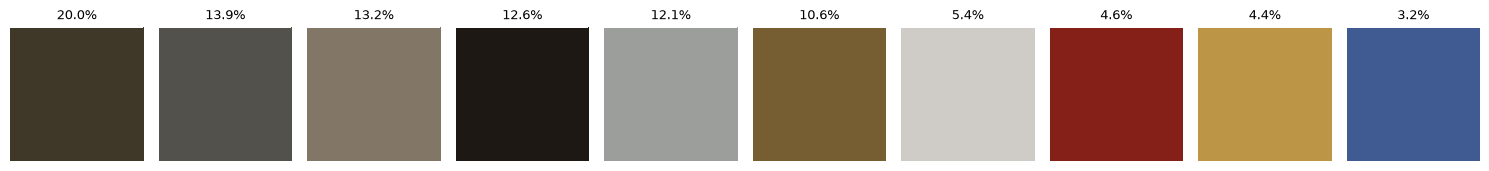

In [23]:
all_pixels = []

for npc_id in df["id"]:
    try:
        img = Image.open(f"../data/bodies/{npc_id}.png").convert("RGBA")
        arr = np.array(img).reshape(-1, 4)
        arr = arr[arr[:, 3] > 0]
        arr = arr[:, :3]
        all_pixels.append(arr)
    except:
        pass

all_pixels = np.vstack(all_pixels)

sample = all_pixels[np.random.default_rng(42).choice(len(all_pixels), size=100_000, replace=False)]

kmeans = KMeans(n_clusters=10, random_state=42, n_init=5)
kmeans.fit(sample)

counts = np.bincount(kmeans.labels_)
colors = kmeans.cluster_centers_[np.argsort(-counts)].astype(int)
pcts = counts[np.argsort(-counts)] / counts.sum() * 100

fig, axes = plt.subplots(1, 10, figsize=(15, 2))
for ax, color, pct in zip(axes, colors, pcts):
    ax.imshow([[color]])
    ax.set_title(f"{pct:.1f}%", fontsize=9)
    ax.axis("off")
plt.tight_layout()
plt.show()